In [0]:
"""
Tenday -- Notebook 03: behavioural segmentation (Layer 3).

MLlib KMeans over the full-window feature table.

Why MLlib rather than scikit-learn here
---------------------------------------
The feature table is 200k rows, which scikit-learn handles comfortably.
MLlib is used so the pipeline stays distributed end to end and the same
code works if the book grows to 20M customers. The honest interview
answer is that at this size it is a design choice about scalability, not
a necessity -- and knowing which is which is the point.

Three things this file does:
  1. selects and prepares features (log-transform, impute, scale)
  2. sweeps k and picks one on silhouette, logged to MLflow
  3. profiles the resulting segments in business language
"""

from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

try:
    import mlflow
    MLFLOW = True
except ImportError:
    MLFLOW = False


# Features used for segmentation. Deliberately excludes:
#   - net_value / gross_revenue / is_profitable  -> outcomes, not behaviour.
#     Clustering on the outcome would just rediscover profitability.
#   - acquisition-time attributes -> we want behavioural segments, and
#     channel/campaign are the things we later explain segments BY.
#   - raw counts already captured as rates.
CLUSTER_FEATURES = [
    "full_total_spend",
    "full_avg_txn",
    "full_txn_count",
    "full_category_hhi",
    "full_liquid_share",
    "full_online_share",
    "full_recurring_share",
    "full_active_day_ratio",
    "full_dormancy_days",
    "full_first30_spend_share",
    "full_last6mo_spend_share",
    "full_distinct_categories",
    "full_distinct_merchants",
    "full_spend_velocity",
]

# Heavily right-skewed -> log1p before scaling, or a handful of large
# spenders define every cluster boundary. (Mean txn 1,702 vs stddev 3,315.)
LOG_FEATURES = [
    "full_total_spend",
    "full_avg_txn",
    "full_txn_count",
    "full_spend_velocity",
    "full_distinct_merchants",
]


def prepare(l3):
    """Impute, log-transform, and return a frame ready for assembly."""
    df = l3

    # Customers with a single transaction have null stddev; customers with
    # no qualifying spend have null shares. Zero is the correct fill for
    # every one of these -- it means 'none of this behaviour occurred'.
    fill = {c: 0.0 for c in CLUSTER_FEATURES}
    df = df.fillna(fill)

    for c in LOG_FEATURES:
        df = df.withColumn(f"log_{c}", F.log1p(F.greatest(F.lit(0.0), F.col(c))))

    return df


def feature_cols():
    """Final input columns: log versions where transformed, raw otherwise."""
    return [f"log_{c}" if c in LOG_FEATURES else c for c in CLUSTER_FEATURES]


def build_pipeline(k, seed=42):
    assembler = VectorAssembler(
        inputCols=feature_cols(), outputCol="features_raw", handleInvalid="skip"
    )
    scaler = StandardScaler(
        inputCol="features_raw", outputCol="features",
        withMean=True, withStd=True,
    )
    kmeans = KMeans(k=k, featuresCol="features", predictionCol="segment",
                    seed=seed, maxIter=50)
    return Pipeline(stages=[assembler, scaler, kmeans])


def sweep_k(df, k_values=range(2, 11), seed=42, sample_frac=None):
    """
    Fit KMeans for each k, score silhouette, return (k, silhouette, model).

    Silhouette measures how well each point sits in its own cluster versus
    the nearest other cluster. Range -1..1; higher is better. It is not the
    only criterion -- a k that scores marginally higher but produces two
    segments a business cannot tell apart is the wrong answer.
    """
    evaluator = ClusteringEvaluator(
        featuresCol="features", predictionCol="segment",
        metricName="silhouette", distanceMeasure="squaredEuclidean",
    )
    scored = df if sample_frac is None else df.sample(False, sample_frac, seed)

    results = []
    for k in k_values:
        model = build_pipeline(k, seed).fit(scored)
        preds = model.transform(scored)
        sil = evaluator.evaluate(preds)
        sizes = (preds.groupBy("segment").count()
                      .orderBy("segment").collect())
        smallest = min(r["count"] for r in sizes) / preds.count()

        results.append({"k": k, "silhouette": sil,
                        "smallest_share": smallest, "model": model})
        print(f"k={k:>2}  silhouette={sil:.4f}  smallest cluster={smallest:.1%}")

        if MLFLOW:
            with mlflow.start_run(run_name=f"kmeans_k{k}", nested=True):
                mlflow.log_param("k", k)
                mlflow.log_param("features", len(feature_cols()))
                mlflow.log_metric("silhouette", sil)
                mlflow.log_metric("smallest_cluster_share", smallest)

    return results


def profile_segments(preds, label_df=None):
    """
    Segment profiles in business terms. This is the deliverable --
    'Cluster 3' means nothing to anyone; 'high spend, diversified,
    never dormant' does.
    """
    agg = preds.groupBy("segment").agg(
        F.count("*").alias("customers"),
        F.round(F.avg("full_total_spend"), 0).alias("avg_spend"),
        F.round(F.avg("full_txn_count"), 0).alias("avg_txns"),
        F.round(F.avg("full_category_hhi"), 3).alias("concentration"),
        F.round(F.avg("full_liquid_share"), 3).alias("liquid_share"),
        F.round(F.avg("full_first30_spend_share"), 3).alias("front_loading"),
        F.round(F.avg("full_dormancy_days"), 0).alias("dormancy_days"),
        F.round(F.avg("full_days_to_qualify"), 1).alias("days_to_qualify"),
        F.round(F.avg("full_redemption_lag"), 1).alias("redeem_lag"),
        F.round(F.avg("net_value"), 0).alias("avg_net_value"),
    ).orderBy("segment")

    if label_df is not None:
        # EVALUATION ONLY -- never joined into the modelling frame.
        purity = (preds.select("customer_id", "segment")
                       .join(label_df, "customer_id")
                       .groupBy("segment")
                       .agg(F.round(F.avg("is_gamer"), 3).alias("actual_gamer_rate")))
        agg = agg.join(purity, "segment").orderBy("segment")

    return agg


def run(spark, out, k=None, write_format="delta", sample_frac=0.25):
    l3 = spark.read.format(write_format).load(f"{out}/features_l3")
    df = prepare(l3)

    print("=== k sweep ===")
    results = sweep_k(df, range(2, 11), sample_frac=sample_frac)

    if k is None:
        # NOTE ON k SELECTION -- this is a judgement call, documented.
        #
        # Silhouette is highest at k=3, but k=3 merges bonus gamers with
        # early churners into one cluster that is ~50% each. Both are
        # dormant and front-loaded; only days-to-qualify separates them.
        # A segment that is half good customers cannot be acted on, so
        # the silhouette-optimal k is the wrong answer here.
        #
        # k=6 resolves them into distinct segments while keeping every
        # cluster above 3% of the book. Silhouette is one input; business
        # separability is the deciding one.
        sil3 = next((r["silhouette"] for r in results if r["k"] == 3), None)
        sil6 = next((r["silhouette"] for r in results if r["k"] == 6), None)
        k = 6
        print(f"\nsilhouette k=3: {sil3:.4f}   k=6: {sil6:.4f}")
        print(f"selected k={k} on business separability -- k=3 merges "
              f"gamers with early churners")

    model = build_pipeline(k).fit(df)
    preds = model.transform(df)

    (preds.select("customer_id", "segment")
          .write.format(write_format).mode("overwrite")
          .save(f"{out}/segments"))

    return model, preds, results

In [0]:
import mlflow
OUT = "/Volumes/workspace/default/tenday"

with mlflow.start_run(run_name="kmeans_sweep"):
    model, preds, results = run(spark, OUT, k=None,
                                write_format="delta", sample_frac=0.25)

{"ts": "2026-09-09 13:03:18.069", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjEzNTg5NjcxNDM4MzA4NBABIAEyJDAxYTA4NjQzLTMzYjgtNzZiOC1hM2RmLTFlMzkwNzk0ZDVlNzokMDU3OTFkNmYtZjFmOS0zNzY5LThlZTItMWY3Y2ExYTM4OTkzSgsI4rGF1QYQgJTQblABWAFgAWjnu+CyksWjDQ==.", "context": {}}
{"ts": "2026-09-09 13:03:18.069", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjEzNTg5NjcxNDM4MzA4NBABIAEyJDAxYTA4NjQzLTMzYjgtNzZiOC1hM2RmLTFlMzkwNzk0ZDVlNzokMDU3OTFkNmYtZjFmOS0zNzY5LThlZTItMWY3Y2ExYTM4OTkzSgsI4rGF1QYQgJTQblABWAFgAWjnu+CyksWjDQ==.", "context": {}}
{"ts": "2026-09-09 13:03:18.069", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjEzNTg5NjcxNDM4MzA4NBABIAEyJDAxYTA4NjQzLTMzYjgtNzZiOC1hM2RmLTFlMzkwNzk0ZDVlNzokMDU3OTFkNmYtZjFmOS0zNzY5LThlZTItMWY3Y2ExYTM4OTkz

=== k sweep ===
k= 2  silhouette=0.4633  smallest cluster=47.8%
k= 3  silhouette=0.5504  smallest cluster=14.6%
k= 4  silhouette=0.5611  smallest cluster=14.2%
k= 5  silhouette=0.4912  smallest cluster=13.4%
k= 6  silhouette=0.5226  smallest cluster=5.0%
k= 7  silhouette=0.5281  smallest cluster=3.5%
k= 8  silhouette=0.5250  smallest cluster=1.8%
k= 9  silhouette=0.5267  smallest cluster=2.4%
k=10  silhouette=0.5277  smallest cluster=1.8%

silhouette k=3: 0.5504   k=6: 0.5226
selected k=6 on business separability -- k=3 merges gamers with early churners


In [0]:
from pyspark.sql import functions as F
lab = spark.read.format("delta").load(f"{OUT}/hidden_labels")

profile_segments(preds, lab).show(truncate=False)

preds.select("customer_id", "segment").join(lab, "customer_id") \
     .groupBy("segment", "true_archetype").count() \
     .orderBy("segment", F.desc("count")).show(40, False)

+-------+---------+---------+--------+-------------+------------+-------------+-------------+---------------+----------+-------------+-----------------+
|segment|customers|avg_spend|avg_txns|concentration|liquid_share|front_loading|dormancy_days|days_to_qualify|redeem_lag|avg_net_value|actual_gamer_rate|
+-------+---------+---------+--------+-------------+------------+-------------+-------------+---------------+----------+-------------+-----------------+
|0      |45120    |44216.0  |58.0    |0.224        |0.231       |0.082        |7.0          |260.8          |44.0      |-709.0       |0.0              |
|1      |84517    |406353.0 |237.0   |0.146        |0.23        |0.059        |1.0          |154.2          |46.0      |3154.0       |0.0              |
|2      |27718    |48766.0  |56.0    |0.282        |0.231       |0.522        |209.0        |96.4           |46.1      |-708.0       |0.004            |
|3      |5040     |26007.0  |22.0    |0.354        |0.256       |0.262        |100

In [0]:
from pyspark.sql import functions as F

SEGMENT_NAMES = {
    0: "Casual Regulars",
    1: "High-Value Core",
    2: "Early Churners",
    3: "Borderline Opportunists",
    4: "Bonus Opportunists",
    5: "Minimal Engagers",
}

name_col = F.lit("Unknown")
for sid, nm in SEGMENT_NAMES.items():
    name_col = F.when(F.col("segment") == sid, F.lit(nm)).otherwise(name_col)

segments = (spark.read.format("delta").load(f"{OUT}/segments")
            .withColumn("segment_name", name_col))
segments.write.format("delta").mode("overwrite").save(f"{OUT}/segments_named")
segments.groupBy("segment", "segment_name").count().orderBy("segment").show(truncate=False)

+-------+-----------------------+-----+
|segment|segment_name           |count|
+-------+-----------------------+-----+
|0      |Casual Regulars        |45120|
|1      |High-Value Core        |84517|
|2      |Early Churners         |27718|
|3      |Borderline Opportunists|5040 |
|4      |Bonus Opportunists     |27871|
|5      |Minimal Engagers       |9734 |
+-------+-----------------------+-----+



## Segment naming

| Seg | Name | n | Avg spend | Concentration | Liquid | Front-load | Dormancy | Days to qualify | Net value |
|---|---|---|---|---|---|---|---|---|---|
| 1 | **High-Value Core** | 84,517 | ₹406k | 0.15 | 0.23 | 0.06 | 1 | 154 | **+₹3,154** |
| 0 | **Casual Regulars** | 45,120 | ₹44k | 0.22 | 0.23 | 0.08 | 7 | 261 | −₹709 |
| 2 | **Early Churners** | 27,718 | ₹49k | 0.28 | 0.23 | **0.52** | 209 | 96 | −₹708 |
| 4 | **Bonus Opportunists** | 27,871 | ₹262k | **0.51** | **0.48** | **0.78** | 210 | **9.8** | **−₹2,676** |
| 5 | **Minimal Engagers** | 9,734 | ₹9k | 0.39 | 0.23 | 0.18 | 84 | never | −₹1,133 |
| 3 | **Borderline Opportunists** | 5,040 | ₹26k | 0.35 | 0.26 | 0.26 | 100 | 24 | −₹1,091 |

### What each segment is

**High-Value Core** — the portfolio. Highest spend, most diversified,
never dormant, and the only segment with positive net value. 42% of
customers, and effectively all of the profit.

**Casual Regulars** — low spend but genuine and sustained. Not dormant,
spread across categories, slow to reach any bonus threshold. Marginally
unprofitable on current offer economics rather than behaviourally
problematic.

**Early Churners** — 52% of their spend lands in the first 30 days, then
they go quiet for 209 days. Superficially they look like gamers, but they
take 96 days to hit the threshold and 46 days to redeem. They lost
interest; they weren't working the offer.

**Bonus Opportunists** — the target. Qualify in 9.8 days, redeem 2.5 days
later, 78% of spend in the first month, half of it in cash-equivalent
categories, then 210 days dormant. Worst net value in the book at −₹2,676.

**Minimal Engagers** — 12 transactions, ₹8,751 of spend, never qualify for
anything. Acquisition cost never recovered, but no active abuse.

**Borderline Opportunists** — the ambiguous segment, and the interesting
one. Qualify in 24 days and redeem in 4.6, so the *timing* pattern matches
gaming, but spend is low (₹26k) and liquid share is normal. These look
like opportunists without the scale. Worth flagging for monitoring rather
than action.

### Validation against held-out ground truth
Segment 4 is **99.8% true gamers**, capturing 27,828 of the 28,490 in the
book (97.7% recall). Segment 3 holds a further 477. Segments 0, 1 and 2
contain essentially none.

### Selection note
Silhouette peaked at k=4 (0.5611) and was 0.5504 at k=3 and 0.5226 at k=6.
k=6 was chosen because lower k merges Bonus Opportunists with Early
Churners — two groups that share dormancy and front-loading but differ
by 10x on days-to-qualify. A segment that mixes them cannot be acted on.
Silhouette measures geometry; segment usefulness is the business
criterion, and here they disagree.

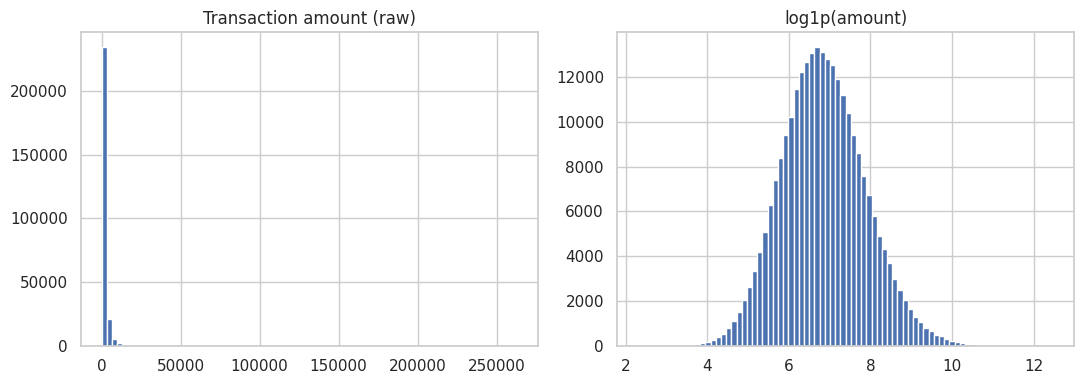

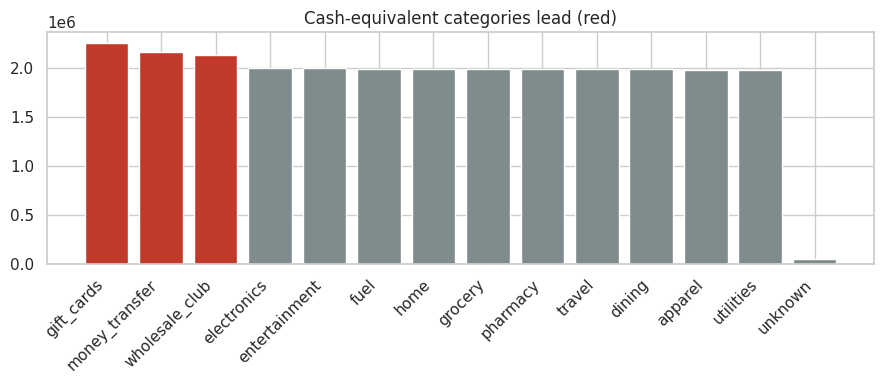

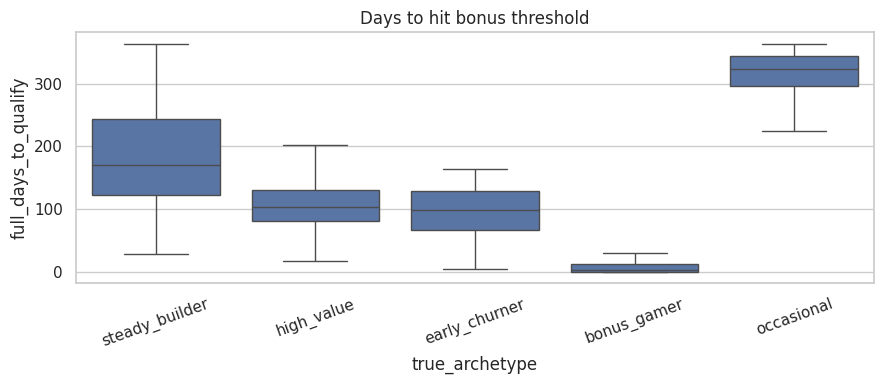

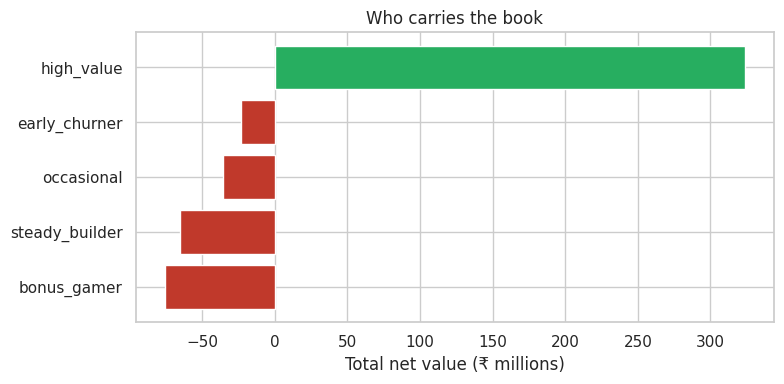

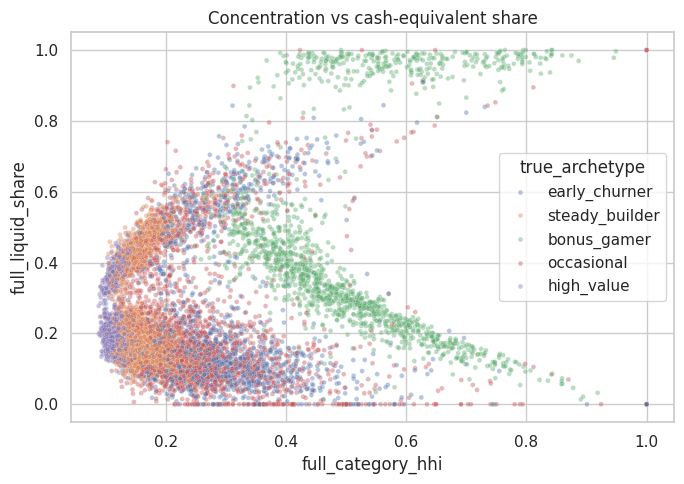

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pyspark.sql import functions as F

OUT = "/Volumes/workspace/default/tenday"
sns.set_theme(style="whitegrid")

txns = spark.read.format("delta").load(f"{OUT}/txns_clean")
l3   = spark.read.format("delta").load(f"{OUT}/features_l3")
lab  = spark.read.format("delta").load(f"{OUT}/hidden_labels")

# 1. Transaction amount distribution (justifies the log transform)
amts = (txns.filter(~F.col("is_refund")).select("abs_amount")
            .sample(False, 0.01, 42).toPandas())
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(amts.abs_amount, bins=80); ax[0].set_title("Transaction amount (raw)")
ax[1].hist(np.log1p(amts.abs_amount), bins=80); ax[1].set_title("log1p(amount)")
plt.tight_layout(); plt.show()

# 2. Category mix — the pre-model signal
cats = (txns.groupBy("merchant_category").count()
            .orderBy(F.desc("count")).toPandas())
plt.figure(figsize=(9, 4))
colors = ["#c0392b" if c in ("gift_cards","money_transfer","wholesale_club")
          else "#7f8c8d" for c in cats.merchant_category]
plt.bar(cats.merchant_category, cats["count"], color=colors)
plt.xticks(rotation=45, ha="right"); plt.title("Cash-equivalent categories lead (red)")
plt.tight_layout(); plt.show()

# 3. Days-to-qualify — the separator
d = l3.join(lab, "customer_id").select(
        "true_archetype", "full_days_to_qualify").dropna().toPandas()
plt.figure(figsize=(9, 4))
sns.boxplot(data=d, x="true_archetype", y="full_days_to_qualify", showfliers=False)
plt.xticks(rotation=20); plt.title("Days to hit bonus threshold")
plt.tight_layout(); plt.show()

# 4. Value concentration
v = l3.join(lab, "customer_id").groupBy("true_archetype").agg(
        F.sum("net_value").alias("total"),
        F.count("*").alias("n")).toPandas().sort_values("total")
plt.figure(figsize=(8, 4))
plt.barh(v.true_archetype, v.total/1e6,
         color=["#c0392b" if x < 0 else "#27ae60" for x in v.total])
plt.xlabel("Total net value (₹ millions)"); plt.title("Who carries the book")
plt.tight_layout(); plt.show()

# 5. The two-feature separation
s = l3.join(lab, "customer_id").sample(False, 0.05, 42).select(
        "full_category_hhi", "full_liquid_share", "true_archetype").toPandas()
plt.figure(figsize=(7, 5))
sns.scatterplot(data=s, x="full_category_hhi", y="full_liquid_share",
                hue="true_archetype", alpha=0.4, s=12)
plt.title("Concentration vs cash-equivalent share")
plt.tight_layout(); plt.show()